In [12]:
import tifffile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os,time
from datetime import datetime

In [ ]:
def transform_image_sift(source_img, dest_img, min_matches=5, background_color=(255, 255, 255)):
    src_gray = cv2.cvtColor(source_img, cv2.COLOR_BGR2GRAY)
    dest_gray = cv2.cvtColor(dest_img, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()

    src_keypoints, src_descriptors = sift.detectAndCompute(src_gray, None)
    dest_keypoints, dest_descriptors = sift.detectAndCompute(dest_gray, None)

    src_height, src_width = source_img.shape[:2]
    dest_height, dest_width = dest_img.shape[:2]
    
    if src_descriptors is None or dest_descriptors is None:
        print("No features found in one or both images")
        return None, False
    
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    matches = flann.knnMatch(src_descriptors, dest_descriptors, k=2) #find matches

    good_matches = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)

    if len(good_matches) < min_matches:
        print(f"Not enough good matches found ({len(good_matches)} < {min_matches})")
        return None, False
    
    src_points = np.float32([src_keypoints[m.queryIdx].pt for m in good_matches])
    dest_points = np.float32([dest_keypoints[m.trainIdx].pt for m in good_matches])

    H, mask = cv2.findHomography(src_points, dest_points, cv2.RANSAC, 5.0)
    
    if H is None:
        print("Could not find valid homography")
        return None, False

    background = np.full((dest_height, dest_width, 3), background_color, dtype=np.uint8)
    
    #transform
    transformed_img = cv2.warpPerspective(
        source_img,
        H,
        (dest_width, dest_height),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_TRANSPARENT
    )

    #create mask
    mask = np.all(transformed_img == 0, axis=2)
    
    result = transformed_img.copy()
    result[mask] = background[mask]

    plt.figure(figsize=(15,5))

    plt.subplot(141)
    plt.imshow(cv2.cvtColor(dest_img, cv2.COLOR_BGR2RGB))
    plt.title('H&E Image')
    plt.axis('off')

    plt.subplot(142)
    plt.imshow(cv2.cvtColor(source_img, cv2.COLOR_BGR2RGB))
    plt.title('IHC image')
    plt.axis('off')

    plt.subplot(143)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title('Transformed Image')
    plt.axis('off')

    return result, True

HE image size (768, 803, 3)
Cropped IHC image size (487, 614, 3)
Elapsed time: 0 minutes 0 seconds


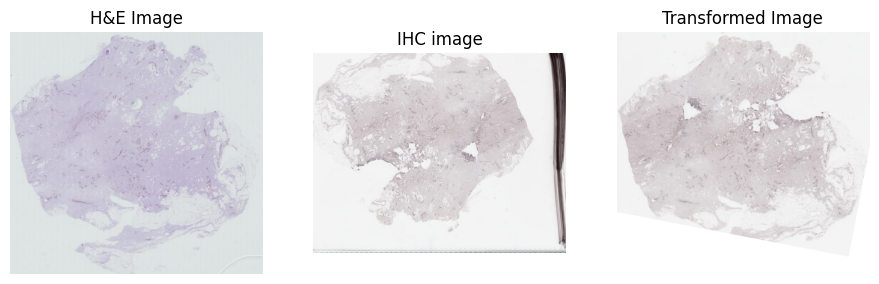

In [14]:
def main():
    start_time = time.time()

    refImagePath = "../SD0158/SD0158.svs"
    ihcImagePath = "../SD0158/SD0158-PDL1.svs"
    with tifffile.TiffFile(refImagePath) as tifhe:
        refImage = tifhe.pages[1].asarray()  #2
    
    with tifffile.TiffFile(ihcImagePath) as tif:
        ihcImage = tif.pages[1].asarray()  #2
    new_width = int(ihcImage.shape[1] * 0.6)
    croppedIhcImage = ihcImage[:, :new_width, :]

    print(f"HE image size {refImage.shape}")
    print(f"Cropped IHC image size {croppedIhcImage.shape}")
    log_file = "../SD0158/log.txt"
    
    with open(log_file, 'a') as f:
        f.write(f"Error log - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Ref image: {refImagePath}\n")
        f.write(f"IHC image: {ihcImagePath}\n")
        f.write("-" * 50 + "\n")

    #transform_image_sift(croppedIhcImage, refImage, min_matches=5)
    transformed_img, success = transform_image_sift(croppedIhcImage, refImage)
    #transform_image_with_perspective(croppedIhcImage, refImage)
    
    if success:
        tifffile.imwrite(
            "../SD0158/Transformed_SD0158-PDL1-level1.tif", 
            transformed_img,
            compression=None,
            dtype=transformed_img.dtype)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    minute = int(elapsed_time // 60)
    second = int(elapsed_time % 60)
    print(f"Elapsed time: {minute} minutes {second} seconds")

if __name__ == '__main__':
    main()